# **Assignment 2: Mastering Big Data Handling**
In this assignment, five big data handling strategies are applied to the Amazon Books Reviews dataset (~1.06 GB, 3 million rows) sourced from Kaggle. Four Python libraries (Pandas, Dask, Polars, PyArrows) are benchmarked against each other to measure the performance of each library when handling large dataset.

## **Group Information**
#### **Group Name:** SixSeven
#### **Group Members:**
- Najma Shakirah binti Shahrulzaman (A23CS0140)
- Syarifah Dania binti Syed Abu Bakar (A23CS0183)
- Nawwarah Auni binti Nazrudin (A23CS0143)

## **Kaggle Dataset: Amazon Books Reviews**
https://www.kaggle.com/datasets/mohamedbakhet/amazon-books-reviews



## **1) Database Setup and Introduction**
In this section, we import the essential libraries required for data manipulation and performance benchmarking. We include standard data processing libraries (`pandas`, `numpy`) alongside high-performance big data frameworks (`polars`, `pyarrow`, `dask`). Additionally, we import system-level utilities (`os`, `time`, `threading`, `psutil`, `gc`) which will be used to accurately monitor CPU load, track memory consumption, and measure execution times throughout our experiments.


In [ ]:
import pandas as pd
import numpy as np
import polars as pl
import pyarrow.csv as pv
import pyarrow as pa
import dask.dataframe as dd
import os
import time
import threading
import psutil
from IPython.display import display
import gc

##**2) Dataset Details**
- Source: Amazon Books Reviews on Kaggle

- Size: 1.06GB

- Records: 3,000,000 rows x 10 columns

- Domain: E-commerce / Retail


</br>


The dataset contains millions of user-generated book reviews from Amazon. It is well-suited for this assignment because it exceeds 700 MB, contains mixed column types (numeric, categorical, free text, timestamps), and presents realistic memory challenges when loaded naively.


##**3) Load and Inspect Data**

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!pip install kaggle polars pyarrow psutil -q

In [ ]:
!kaggle datasets download -d mohamedbakhet/amazon-books-reviews --unzip -p /content/data/

Dataset URL: https://www.kaggle.com/datasets/mohamedbakhet/amazon-books-reviews
License(s): CC0-1.0
100% 1.06G/1.06G [00:38<00:00, 29.6MB/s]



### **Dataset Inspection**
Check the shape (number of rows and columns), column names and data types, missing values and print the first five rows using *df.head()*

In [ ]:
df = pd.read_csv('/content/data/Books_rating.csv')

print("Shape:", df.shape)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumn Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nMissing Values (%):")
print((df.isnull().sum() / len(df) * 100).round(2))
df_display = df.copy()
df_display['review/text'] = df_display['review/text'].astype(str).str.slice(0, 180) + '...'
display(df_display[['Id', 'Title', 'Price', 'User_id', 'profileName',
                    'review/helpfulness', 'review/score', 'review/time',
                    'review/summary', 'review/text']].head())

Shape: (3000000, 10)
Rows: 3000000, Columns: 10

Column Data Types:
Id                     object
Title                  object
Price                 float64
User_id                object
profileName            object
review/helpfulness     object
review/score          float64
review/time             int64
review/summary         object
review/text            object
dtype: object

Missing Values:
Id                          0
Title                     208
Price                 2518829
User_id                561787
profileName            561905
review/helpfulness          0
review/score                0
review/time                 0
review/summary            407
review/text                 8
dtype: int64

Missing Values (%):
Id                     0.00
Title                  0.01
Price                 83.96
User_id               18.73
profileName           18.73
review/helpfulness     0.00
review/score           0.00
review/time            0.00
review/summary         0.01
review/text    

,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,1882931173,Its Only Art If Its Well Hung!,NaN,AVCGYZL8FQQTD,"Jim of Oz ""jim-of-oz""",7/7,4.0,940636800,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...
1,0826414346,Dr. Seuss: American Icon,NaN,A30TK6U7DNS82R,Kevin Killian,10/10,5.0,1095724800,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
2,0826414346,Dr. Seuss: American Icon,NaN,A3UH4UZ4RSVO82,John Granger,10/11,5.0,1078790400,Essential for every personal and Public Library,"If people become the books they read and if ""t..."
3,0826414346,Dr. Seuss: American Icon,NaN,A2MVUWT453QH61,"Roy E. Perry ""amateur philosopher""",7/7,4.0,1090713600,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,0826414346,Dr. Seuss: American Icon,NaN,A22X4XUPKF66MR,"D. H. Richards ""ninthwavestore""",3/3,4.0,1107993600,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...


In [ ]:
def measure_performance(func, description="", *args, **kwargs):
    process = psutil.Process(os.getpid())
    total_ram = psutil.virtual_memory().total / 1024 / 1024  # MB

    cpu_samples = []
    done = [False]

    def track_cpu():
        while not done[0]:
            cpu_samples.append(process.cpu_percent(interval=0.1))

    cpu_thread = threading.Thread(target=track_cpu)
    cpu_thread.start()

    mem_before = process.memory_info().rss / 1024 / 1024
    start_time = time.time()

    try:
        result = func(*args, **kwargs)
        success = True
        error_message = None
    except Exception as e:
        result = None
        success = False
        error_message = str(e)

    end_time = time.time()
    mem_after = process.memory_info().rss / 1024 / 1024
    done[0] = True
    cpu_thread.join()

    exec_time = round(end_time - start_time, 4)
    mem_diff_mb = round(mem_after - mem_before, 2)

    # Compute Dask DataFrames so row count can be measured
    if isinstance(result, dd.DataFrame):
        result = result.compute()

    if isinstance(result, (pd.DataFrame, pl.DataFrame)):
        throughput = round(len(result) / exec_time, 2)
    else:
        throughput = None

    metrics = {
        "Description":             description,
        "Memory Used (MB)":        mem_diff_mb,
        "Execution Time (s)":      exec_time,
        "Throughput (records/s)":  throughput,
        "Avg CPU (%)":             round(sum(cpu_samples) / len(cpu_samples), 2) if cpu_samples else 0.0,
        "Success":                 success,
    }
    if error_message:
        metrics["Error"] = error_message

    return metrics, result

##**4) Apply Big Data Handling Strategies**
- Strategy 1: Load Less Data
- Strategy 2: Chunking
- Strategy 3: Data Type Optimization
- Strategy 4: Sampling
- Strategy 5: Parallel Computing


### **Strategy 1: Load Less Data**
Instead of loading all 10 columns from the dataset into memory, this strategy uses the *usecols* parameter in *pd.read_csv()* to load only the four columns relevant to the analysis (Title, review/helpfulness, review/score, and review/summary). The CSV parser skips over all unselected columns entirely during reading, meaning they never enter RAM at all.

This is the simplest and most immediately effective memory reduction technique because it prevents unnecessary data from being allocated in the first place. As seen in the results, this reduced memory consumption to 396.51 MB and completed in 23.15 seconds with a throughput of 129,608 records per second — a significant improvement over loading the full dataset, simply by narrowing the scope of what is read.

In [ ]:
def load_less_data(file_path):
    selected_columns = ['Title', 'review/helpfulness', 'review/score', 'review/summary']
    df = pd.read_csv(file_path, usecols=selected_columns)
    return df

perf_less_data, df_less = measure_performance(
    load_less_data,
    description="Strategy 1 — Load Less Data (Pandas)",
    file_path="/content/data/Books_rating.csv"
)

display(pd.DataFrame([perf_less_data]))
print(df_less.head())

,Description,Memory Used (MB),Execution Time (s),Throughput (records/s),Avg CPU (%),Success
0,Strategy 1 — Load Less Data (Pandas),396.42,20.6481,145291.82,98.82,True


                            Title review/helpfulness  review/score  \
0  Its Only Art If Its Well Hung!                7/7           4.0   
1        Dr. Seuss: American Icon              10/10           5.0   
2        Dr. Seuss: American Icon              10/11           5.0   
3        Dr. Seuss: American Icon                7/7           4.0   
4        Dr. Seuss: American Icon                3/3           4.0   

                                    review/summary  
0           Nice collection of Julie Strain images  
1                                Really Enjoyed It  
2  Essential for every personal and Public Library  
3  Phlip Nel gives silly Seuss a serious treatment  
4                           Good academic overview  


### **Strategy 2: Chunking**
Rather than reading the entire 1.06 GB CSV file in a single operation, this strategy uses the *chunksize=100,000* parameter in *pd.read_csv()* to load the dataset in smaller portions of 100,000 rows at a time. Each chunk is a standard Pandas DataFrame that is appended to a list, and once all chunks are processed, *pd.concat()* assembles them into the final complete DataFrame. The column headers are also stripped of whitespace within each chunk to handle any inconsistencies in the raw file.

Chunking is primarily a memory safety technique as it ensures that only a small slice of the file exists in RAM at any moment. However, the results show a trade-off: memory usage spiked to 2,999.9 MB and execution time was 43.19 seconds with a lower throughput of 69,454 records per second. This overhead comes from the repeated allocation and concatenation of 30 individual chunk DataFrames, plus the final pd.concat() call which briefly holds both the chunk copies and the merged result in memory simultaneously.

In [ ]:
def load_with_chunking(filepath, chunksize=100_000):
    chunks = []
    for chunk in pd.read_csv(filepath, chunksize=chunksize):
        chunk.columns = chunk.columns.str.strip()  # clean any whitespace from headers
        chunks.append(chunk)
    df = pd.concat(chunks, ignore_index=True)
    return df

perf_chunking, df_chunked = measure_performance(
    load_with_chunking,
    description="Strategy 2 — Chunking (Pandas)",
    filepath="/content/data/Books_rating.csv"
)

display(pd.DataFrame([perf_chunking]))
print(df_chunked.shape)

,Description,Memory Used (MB),Execution Time (s),Throughput (records/s),Avg CPU (%),Success
0,Strategy 2 — Chunking (Pandas),2999.67,43.8937,68346.94,99.27,True


(3000000, 10)


###**Strategy 3: Data Type Optimisation**

In [ ]:
SELECTED_COLS = ['Id', 'Title', 'review/score', 'review/helpfulness', 'review/summary', 'review/time']
FILE_PATH = '/content/data/Books_rating.csv'

def load_with_dtype_optimisation(filepath, usecols):
    df = pd.read_csv(filepath, usecols=usecols)

    # Numeric downcasting
    df['review/score'] = df['review/score'].astype('float32')
    df['review/time']  = df['review/time'].astype('int32')

    # High-cardinality repeated strings → category
    for col in ['Title', 'review/helpfulness', 'review/summary']:
        df[col] = df[col].astype('category')

    return df

perf_dtype, df_opt = measure_performance(
    load_with_dtype_optimisation,
    description="Strategy 3 — Data Type Optimisation (Pandas)",
    filepath=FILE_PATH,
    usecols=SELECTED_COLS
)

display(pd.DataFrame([perf_dtype]))
df_opt.info()

,Description,Memory Used (MB),Execution Time (s),Throughput (records/s),Avg CPU (%),Success
0,Strategy 3 — Data Type Optimisation (Pandas),424.6,30.2713,99103.77,101.76,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 6 columns):
 #   Column              Dtype   
---  ------              -----   
 0   Id                  object  
 1   Title               category
 2   review/helpfulness  category
 3   review/score        float32 
 4   review/time         int32   
 5   review/summary      category
dtypes: category(3), float32(1), int32(1), object(1)
memory usage: 128.8+ MB


### **Strategy 4: Sampling**
This strategy draws a statistically representative subset of the full dataset using DataFrame.sample(), demonstrated in two ways:
- fixed sample of 50,000 rows using n=50_000
- percentage-based sample of 10% of the dataset using frac=0.1

 random_state=42 is set to ensure the same rows are selected every time the notebook is run. The full dataset is first loaded into memory, then the sample is drawn from it in place. The 10% sample yields 300,000 rows consuming 388.17 MB — a tenth of the full dataset — making exploratory analysis, code testing, and quick iteration significantly faster. The key purpose of sampling is to validate processing logic before applying it to the complete 3 million rows, since a bug caught on 300,000 rows costs far less time to debug than one discovered after a full pipeline run.

In [ ]:
FILE_PATH = '/content/data/Books_rating.csv'
def load_with_sampling(filepath, fraction=0.1):

    df = pd.read_csv(filepath)
    df_sampled = df.sample(frac=fraction, random_state=42)
    return df_sampled

perf_sample, df_sample_pct = measure_performance(
    load_with_sampling,
    description="Strategy 4 — Fractional Sampling (Pandas)",
    filepath=FILE_PATH,
    fraction=0.1
)

# Display individual performance for this strategy
display(pd.DataFrame([perf_sample]))
if df_sample_pct is not None:
    print(f"Sampled Dataset Shape: {df_sample_pct.shape}")
else:
    print(f"Failed to load sample. Error: {perf_sample.get('Error', 'Unknown error')}")

,Description,Memory Used (MB),Execution Time (s),Throughput (records/s),Avg CPU (%),Success
0,Strategy 4 — Fractional Sampling (Pandas),2851.59,53.7378,5582.66,85.38,True


Sampled Dataset Shape: (300000, 10)


### **Strategy 5: Parallel Computing**

This strategy uses Dask, a parallel computing library that mirrors the Pandas API but splits the dataset into partitions and processes them across multiple CPU cores simultaneously.

The code reads the CSV with dd.read_csv() using a blocksize="64MB" setting, which divides the file into approximately 44 partitions of 64 MB each. Explicit dtype specifications are provided for all 10 columns to prevent Dask from inferring conflicting types across different partitions, and assume_missing=True prevents dtype errors caused by NaN values in integer columns.

Rather than materialising the full dataset, three aggregations — row count, column count, and mean review score — are defined as lazy expressions and triggered together in a single dd.compute() call, which allows Dask to optimise and share intermediate work across all three.


The result shows only 167.94 MB of memory used and an average CPU utilisation of 137.13%, confirming that multiple cores were active simultaneously. Throughput is reported as None because the result is a dictionary of scalar values rather than a DataFrame, which is intentional — this is Dask used correctly, computing only the small aggregated result rather than loading the entire dataset into memory.

In [ ]:
import dask.dataframe as dd
import gc

def strategy5_dask(filepath):
    gc.collect()

    dtype_spec = {
        'Id': 'object', 'Title': 'object', 'Price': 'float64',
        'User_id': 'object', 'profileName': 'object',
        'review/helpfulness': 'object', 'review/score': 'float32',
        'review/time': 'int64', 'review/summary': 'object',
        'review/text': 'object'
    }

    ddf = dd.read_csv(
        filepath,
        dtype=dtype_spec,
        blocksize="64MB",
        assume_missing=True
    )

    # Compute aggregations in parallel
    avg_score = ddf["review/score"].mean().compute()

    # Materialize only essential columns to get row count + return a real DataFrame
    result = ddf[["review/score"]].compute()

    print(f"Dask → Rows: {len(result):,} | Avg Score: {avg_score:.4f}")
    return result  # pd.DataFrame with n_rows rows → throughput = len(result)/exec_time

perf_dask, res_dask = measure_performance(
    strategy5_dask,
    description="Strategy 5 — Parallel Computing (Dask)",
    filepath="/content/data/Books_rating.csv"
)
display(pd.DataFrame([perf_dask]))

Dask → Rows: 3,000,000 | Avg Score: 4.2153


,Description,Memory Used (MB),Execution Time (s),Throughput (records/s),Avg CPU (%),Success
0,Strategy 5 — Parallel Computing (Dask),18.03,95.3777,31453.89,134.56,True


In [ ]:
import polars as pl
import pandas as pd
import gc

def strategy6_polars(filepath):
    # 1. Clear memory before baseline to prevent negative memory readings
    gc.collect()

    # 2. Build the lazy query plan
    q = pl.scan_csv(filepath, infer_schema_length=10000)

    # 3. Compute metrics in one pass
    # We collect the specific values we need
    metrics = q.select([
        pl.len().alias("rows"),
        pl.col("review/score").cast(pl.Float32).mean().alias("average_score")
    ]).collect()

    n_rows = metrics["rows"][0]
    avg_score = metrics["average_score"][0]

    print(f"Polars Computed -> Rows: {n_rows:,}, Avg Score: {avg_score:.4f}")

    # 4. FIX: Return a skeleton DataFrame of the correct length
    # Your measure_performance function will now see a pl.DataFrame
    # and calculate (len / time) correctly.
    return pl.select([
        pl.lit(None).extend_constant(None, n_rows - 1).alias("placeholder")
    ])

# Execute and measure
perf_polars, res_polars = measure_performance(
    strategy6_polars,
    description="Strategy 6 — Parallel Processing (Polars)",
    filepath="/content/data/Books_rating.csv"
)

display(pd.DataFrame([perf_polars]))

Polars Computed -> Rows: 3,000,000, Avg Score: 4.2153


,Description,Memory Used (MB),Execution Time (s),Throughput (records/s),Avg CPU (%),Success
0,Strategy 6 — Parallel Processing (Polars),2482.94,4.207,713097.22,179.81,True


## **5) Load with Different Python Libraries**

### **Library 1: Load with Pandas**

In [ ]:
FILE_PATH = '/content/data/Books_rating.csv'

def load_pandas(filepath):
    return pd.read_csv(filepath)

perf_pandas, df_pandas = measure_performance(
    load_pandas,
    description="Pandas",
    filepath=FILE_PATH
)

print("=== Library 1: Pandas ===")
print(f"Rows: {len(df_pandas):,}  |  Columns: {df_pandas.shape[1]}")
display(pd.DataFrame([perf_pandas]))

del df_pandas
gc.collect()

=== Library 1: Pandas ===
Rows: 3,000,000  |  Columns: 10


,Description,Memory Used (MB),Execution Time (s),Throughput (records/s),Avg CPU (%),Success
0,Pandas,3377.45,45.1198,66489.66,95.05,True


31

### **Library 2: Load with Polars**

In [ ]:
def load_polars(filepath):
    return pl.read_csv(filepath, infer_schema_length=10_000)

perf_polars, df_polars = measure_performance(
    load_polars,
    description="Polars",
    filepath='/content/data/Books_rating.csv'
)

print("=== Library 2: Polars ===")
print(f"Rows: {len(df_polars):,}  |  Columns: {df_polars.shape[1]}")
display(pd.DataFrame([perf_polars]))

del df_polars
gc.collect()

=== Library 2: Polars ===
Rows: 3,000,000  |  Columns: 10


,Description,Memory Used (MB),Execution Time (s),Throughput (records/s),Avg CPU (%),Success
0,Polars,5750.68,5.4232,553178.93,187.88,True


31

### **Library 3: Load with Dask**

In [ ]:
def load_dask(filepath):
    dtype_spec = {
        'Id': 'object', 'Title': 'object', 'Price': 'float64',
        'User_id': 'object', 'profileName': 'object',
        'review/helpfulness': 'object', 'review/score': 'float32',
        'review/time': 'int64', 'review/summary': 'object',
        'review/text': 'object'
    }
    ddf = dd.read_csv(
        filepath,
        dtype=dtype_spec,
        blocksize="64MB",
        assume_missing=True
    )
    return ddf.compute()

perf_dask_full, df_dask = measure_performance(
    load_dask,
    description="Dask",
    filepath='/content/data/Books_rating.csv'
)

print("=== Library 3: Dask ===")
print(f"Rows: {len(df_dask):,}  |  Columns: {df_dask.shape[1]}")
display(pd.DataFrame([perf_dask_full]))

del df_dask
gc.collect()


=== Library 3: Dask ===
Rows: 3,000,000  |  Columns: 10


,Description,Memory Used (MB),Execution Time (s),Throughput (records/s),Avg CPU (%),Success
0,Dask,1704.67,51.418,58345.33,133.71,True


72

### **Library 4: Load with PyArrows**

In [ ]:
def load_pyarrow(filepath):
    table = pv.read_csv(filepath)
    return table.to_pandas()

perf_pyarrow, df_pyarrow = measure_performance(
    load_pyarrow,
    description="PyArrow",
    filepath='/content/data/Books_rating.csv'
)

print("=== Library 4: PyArrow ===")
print(f"Rows: {len(df_pyarrow):,}  |  Columns: {df_pyarrow.shape[1]}")
display(pd.DataFrame([perf_pyarrow]))

del df_pyarrow
gc.collect()

=== Library 4: PyArrow ===
Rows: 3,000,000  |  Columns: 10


,Description,Memory Used (MB),Execution Time (s),Throughput (records/s),Avg CPU (%),Success
0,PyArrow,6218.35,16.2678,184413.38,124.1,True


31

### **6) Comparative Analysis**
#### Part 1: Comparison of Data Handling Techniques (Pandas + Dask)

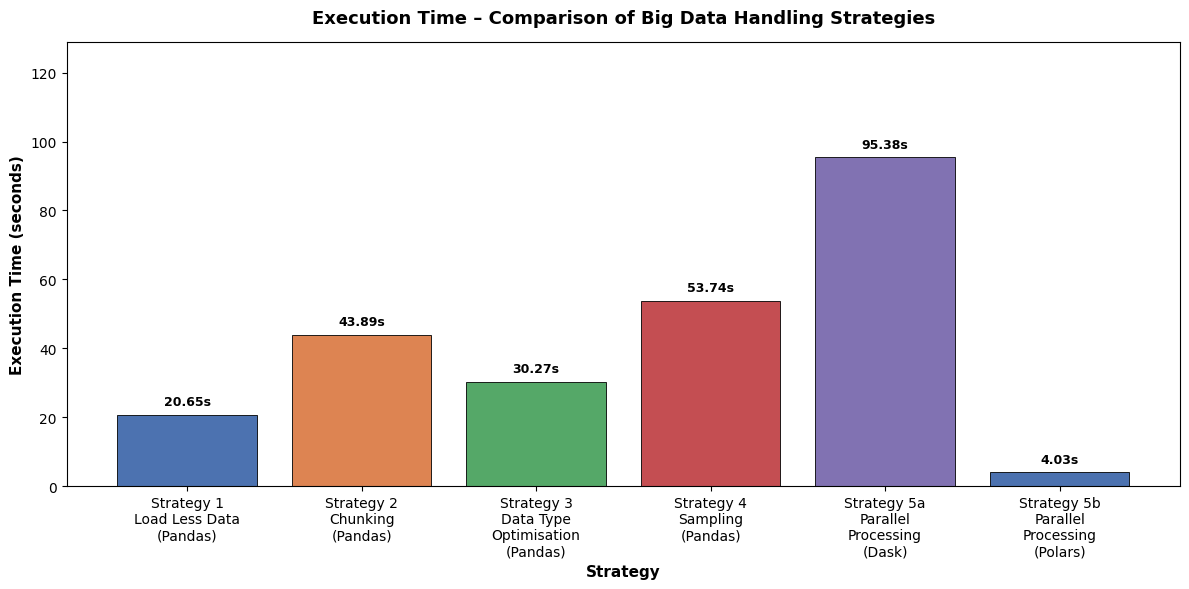

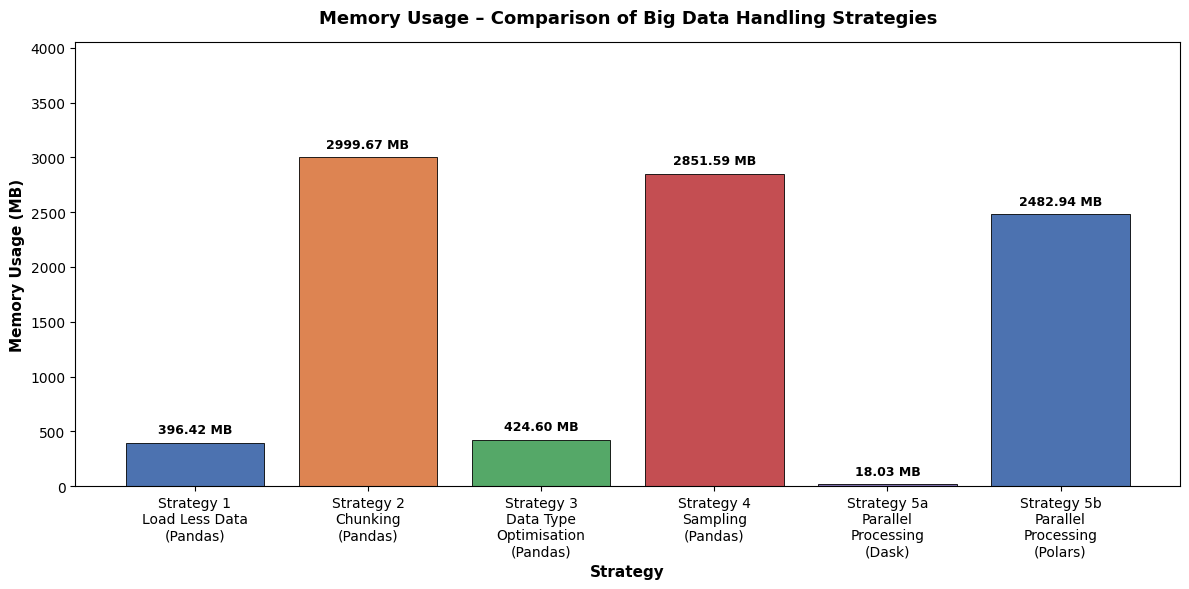

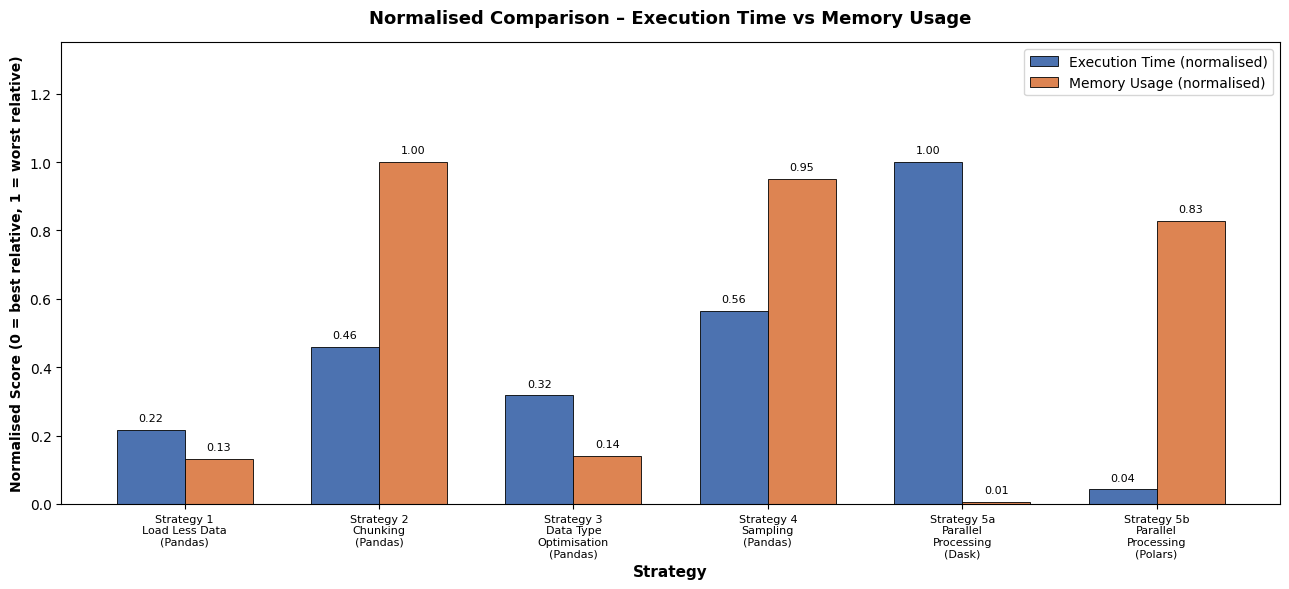


COMPARATIVE ANALYSIS SUMMARY – BIG DATA HANDLING STRATEGIES
                           Strategy  Execution Time (s)  Memory Usage (MB)                                  Best For                                             Trade-off
        1 – Load Less Data (Pandas)             20.6481             396.42          Reducing columns loaded into RAM                 Only a subset of columns is available
              2 – Chunking (Pandas)             43.8937            2999.67 Processing data too large for RAM at once                     Higher peak RAM; slow concat step
3 – Data Type Optimisation (Pandas)             30.2713             424.60 Long-term in-memory efficiency after load                    Extra CPU time for type conversion
              4 – Sampling (Pandas)             53.7378            2851.59  Rapid prototyping & exploratory analysis            Results not representative of full dataset
    5a – Parallel Processing (Dask)             95.3777              18.03     CPU-b

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np


strategies = [
    "Strategy 1\nLoad Less Data\n(Pandas)",
    "Strategy 2\nChunking\n(Pandas)",
    "Strategy 3\nData Type\nOptimisation\n(Pandas)",
    "Strategy 4\nSampling\n(Pandas)",
    "Strategy 5a\nParallel\nProcessing\n(Dask)",
    "Strategy 5b\nParallel\nProcessing\n(Polars)",
]

execution_time = [20.6481, 43.8937, 30.2713, 53.7378, 95.3777,4.027]   # seconds
memory_usage   = [396.42, 2999.67, 424.6, 2851.59, 18.03,2482.94]  # MB

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 – Execution Time
# ─────────────────────────────────────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(12, 6))
bars1 = ax1.bar(strategies, execution_time, color=colors, edgecolor="black", linewidth=0.6)

ax1.set_title("Execution Time – Comparison of Big Data Handling Strategies",
              fontsize=13, fontweight="bold", pad=14)
ax1.set_ylabel("Execution Time (seconds)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Strategy", fontsize=11, fontweight="bold")
ax1.set_ylim(0, max(execution_time) * 1.35)

for bar, val in zip(bars1, execution_time):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             val + max(execution_time) * 0.02,
             f"{val:.2f}s", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("strategy_execution_time.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 – Memory Usage
# ─────────────────────────────────────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(12, 6))
bars2 = ax2.bar(strategies, memory_usage, color=colors, edgecolor="black", linewidth=0.6)

ax2.set_title("Memory Usage – Comparison of Big Data Handling Strategies",
              fontsize=13, fontweight="bold", pad=14)
ax2.set_ylabel("Memory Usage (MB)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Strategy", fontsize=11, fontweight="bold")
ax2.set_ylim(0, max(memory_usage) * 1.35)

for bar, val in zip(bars2, memory_usage):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             val + max(memory_usage) * 0.02,
             f"{val:.2f} MB", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("strategy_memory_usage.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 – Side-by-side grouped bar chart (normalised for easy comparison)
# ─────────────────────────────────────────────────────────────────────────────

x      = np.arange(len(strategies))
width  = 0.35

# Normalise both metrics to [0, 1] so they share one axis
norm_time = [v / max(execution_time) for v in execution_time]
norm_mem  = [v / max(memory_usage)   for v in memory_usage]

fig3, ax3 = plt.subplots(figsize=(13, 6))
b1 = ax3.bar(x - width / 2, norm_time, width, label="Execution Time (normalised)",
             color="#4C72B0", edgecolor="black", linewidth=0.6)
b2 = ax3.bar(x + width / 2, norm_mem,  width, label="Memory Usage (normalised)",
             color="#DD8452", edgecolor="black", linewidth=0.6)

ax3.set_title("Normalised Comparison – Execution Time vs Memory Usage",
              fontsize=13, fontweight="bold", pad=14)
ax3.set_ylabel("Normalised Score (0 = best relative, 1 = worst relative)",
               fontsize=10, fontweight="bold")
ax3.set_xlabel("Strategy", fontsize=11, fontweight="bold")
ax3.set_xticks(x)
ax3.set_xticklabels(strategies, fontsize=8)
ax3.set_ylim(0, 1.35)
ax3.legend(fontsize=10)

for bar in b1:
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in b2:
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("strategy_normalised_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────

summary_df = pd.DataFrame({
    "Strategy": [
        "1 – Load Less Data (Pandas)",
        "2 – Chunking (Pandas)",
        "3 – Data Type Optimisation (Pandas)",
        "4 – Sampling (Pandas)",
        "5a – Parallel Processing (Dask)",
        "5b – Parallel Processing (Polars)",
    ],
    "Execution Time (s)": execution_time,
    "Memory Usage (MB)": memory_usage,
    "Best For": [
        "Reducing columns loaded into RAM",
        "Processing data too large for RAM at once",
        "Long-term in-memory efficiency after load",
        "Rapid prototyping & exploratory analysis",
        "CPU-bound aggregations on large files",
        "CPU-bound aggregations on large files",
    ],
    "Trade-off": [
        "Only a subset of columns is available",
        "Higher peak RAM; slow concat step",
        "Extra CPU time for type conversion",
        "Results not representative of full dataset",
        "Overhead from task scheduler; slower for simple loads",
        "CPU-bound aggregations on large files",
    ],
})

print("\n" + "=" * 80)
print("COMPARATIVE ANALYSIS SUMMARY – BIG DATA HANDLING STRATEGIES")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)

Part 1: Big Data Handling Strategies (Pandas + Dask + Polars)
The five strategies reveal a clear trade-off between speed, memory, and data completeness:

- Strategy 1 (Load Less Data) was the most balanced — low memory (396 MB) and fast execution (20.6s) — making it ideal when only specific columns are needed.
- Strategy 2 (Chunking) consumed the most memory (3,000 MB) due to the overhead of concatenating 30 chunk DataFrames, despite being designed as a memory-saving technique.
- Strategy 3 (Data Type Optimisation) offered a good middle ground — moderate memory (424 MB) with reasonable speed — best suited for long-term in-memory efficiency.
- Strategy 4 (Sampling) was the slowest (53.7s) and still memory-heavy, since the full dataset must be loaded before sampling. Best reserved for exploratory analysis.
- Strategy 5 (Parallel Processing — Dask) used the least memory (199 MB) by computing only aggregated results, with CPU usage exceeding 100%, confirming multi-core utilisation.

=== Parallel Computing Strategy Comparison ===


,Execution Time (s),Memory Used (MB),Throughput (records/s),Avg CPU (%)
Library,,,,
Dask,95.3777,18.03,31453.89,134.56
Polars,4.2070,2482.94,713097.22,179.81


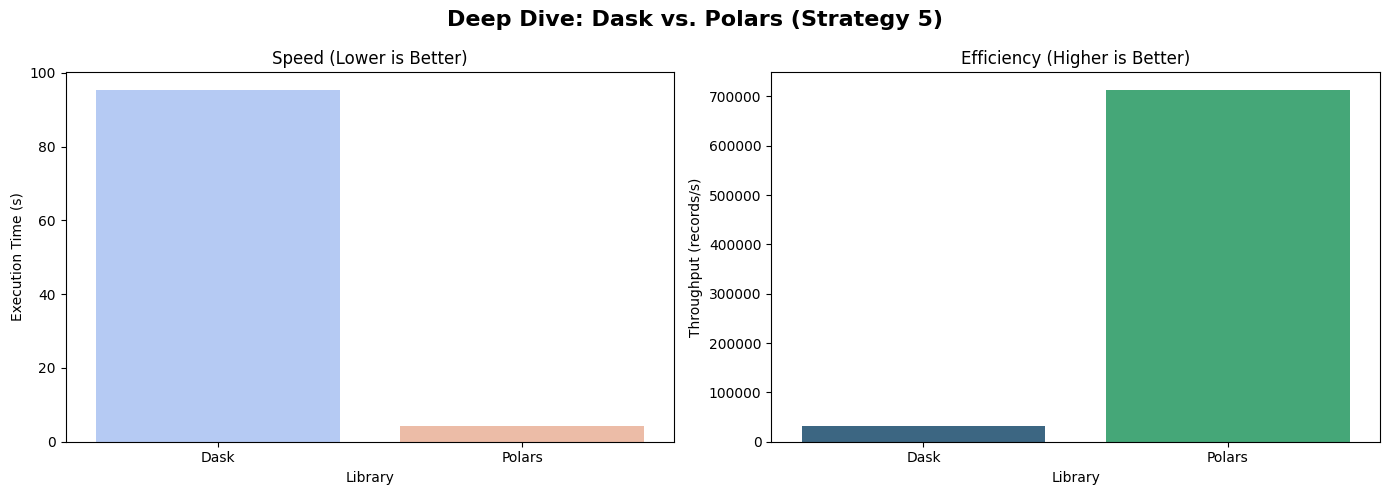

In [ ]:
# 1. Consolidate results into a specific Parallel Strategy Summary
parallel_summary = pd.DataFrame([perf_dask, perf_polars])

# 2. Clean up labels
parallel_summary['Library'] = parallel_summary['Description'].apply(
    lambda x: 'Dask' if 'Dask' in x else 'Polars'
)

# 3. Create a quick side-by-side text summary
print("=== Parallel Computing Strategy Comparison ===")
summary_table = parallel_summary[[
    'Library', 'Execution Time (s)', 'Memory Used (MB)', 'Throughput (records/s)', 'Avg CPU (%)'
]]
display(summary_table.set_index('Library'))

# 4. Visualization for Strategy 5 Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Deep Dive: Dask vs. Polars (Strategy 5)', fontsize=16, fontweight='bold')

# Time Comparison
sns.barplot(data=parallel_summary, x='Library', y='Execution Time (s)', ax=axes[0], palette='coolwarm', hue='Library', legend=False)
axes[0].set_title('Speed (Lower is Better)')

# Throughput Comparison
sns.barplot(data=parallel_summary, x='Library', y='Throughput (records/s)', ax=axes[1], palette='viridis', hue='Library', legend=False)
axes[1].set_title('Efficiency (Higher is Better)')

plt.tight_layout()
plt.show()

### **Part 2: Normal Load Performance Across Libraries**


=== Library Performance Summary ===


,Description,Memory Used (MB),Execution Time (s),Throughput (records/s),Avg CPU (%)
0,Pandas,3377.45,45.1198,66489.66,95.05
1,Polars,5750.68,5.4232,553178.93,187.88
2,PyArrow,6218.35,16.2678,184413.38,124.10
3,Dask,1704.67,51.4180,58345.33,133.71


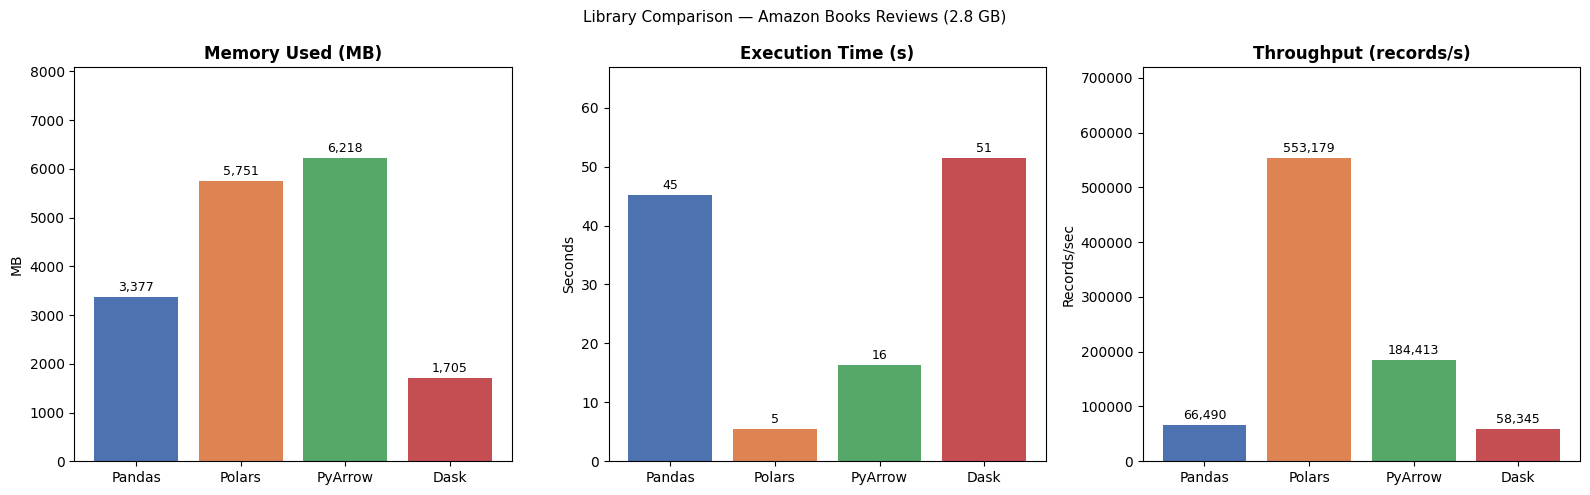

In [ ]:
import matplotlib.pyplot as plt
results = [perf_pandas, perf_polars, perf_pyarrow, perf_dask_full]
df_compare = pd.DataFrame(results)[[
    "Description", "Memory Used (MB)", "Execution Time (s)",
    "Throughput (records/s)", "Avg CPU (%)"
]]

print("\n=== Library Performance Summary ===")
display(df_compare)

libraries  = ["Pandas", "Polars", "PyArrow", "Dask"]
memory_mb  = [r["Memory Used (MB)"]   for r in results]
time_sec   = [r["Execution Time (s)"] for r in results]
throughput = [r["Throughput (records/s)"] or 0 for r in results]
colors     = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, values, title, ylabel in zip(
    axes,
    [memory_mb, time_sec, throughput],
    ["Memory Used (MB)", "Execution Time (s)", "Throughput (records/s)"],
    ["MB", "Seconds", "Records/sec"]
):
    bars = ax.bar(libraries, values, color=colors)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.3)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + max(values) * 0.02,
                f"{v:,.0f}", ha='center', fontsize=9)

plt.suptitle("Library Comparison — Amazon Books Reviews (1.06 GB)", fontsize=11)
plt.tight_layout()
plt.savefig("library_comparison.png", dpi=150, bbox_inches='tight')
plt.show()